In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
import warnings
warnings.filterwarnings('ignore')

In [2]:
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_labels.csv').values.ravel()
print(f"Loaded features: {X.shape}")
print(f"Anomaly ratio: {y.mean():.2%}")

# Load scaler and cluster results
import joblib
scaler = joblib.load('../data/models/scaler.pkl')
kmeans = joblib.load('../data/models/kmeans_model.pkl')
anomaly_threshold = joblib.load('../data/models/anomaly_threshold.pkl')

Loaded features: (10000, 28)
Anomaly ratio: 50.00%


In [3]:
print("="*60)
print("ISOLATION FOREST ANOMALY DETECTION")
print("="*60)

# Test different contamination levels
contamination_levels = [0.1, 0.2, 0.3, 0.4, 0.5]
isolation_results = []

for contam in contamination_levels:
    iso_forest = IsolationForest(contamination=contam, random_state=42, n_estimators=100)
    iso_pred = iso_forest.fit_predict(X)
    # Convert to binary (1 for anomaly, 0 for normal)
    iso_anomaly = (iso_pred == -1).astype(int)
    
    # Calculate detection rate
    detection_rate = (iso_anomaly == 1).mean()
    true_positive_rate = ((iso_anomaly == 1) & (y == 1)).sum() / (y == 1).sum()
    
    isolation_results.append({
        'contamination': contam,
        'detection_rate': detection_rate,
        'true_positive_rate': true_positive_rate,
        'model': iso_forest
    })
    
    print(f"Contamination={contam}: Detection Rate={detection_rate:.2%}, TPR={true_positive_rate:.2%}")

# Best model based on TPR
best_iso = max(isolation_results, key=lambda x: x['true_positive_rate'])
print(f"\nBest Isolation Forest: contamination={best_iso['contamination']}, TPR={best_iso['true_positive_rate']:.2%}")

# Train final Isolation Forest
iso_forest_final = IsolationForest(contamination=best_iso['contamination'], random_state=42, n_estimators=100)
iso_forest_final.fit(X)
iso_anomaly_final = (iso_forest_final.predict(X) == -1).astype(int)

ISOLATION FOREST ANOMALY DETECTION
Contamination=0.1: Detection Rate=10.00%, TPR=12.12%
Contamination=0.2: Detection Rate=20.00%, TPR=24.24%
Contamination=0.3: Detection Rate=30.00%, TPR=38.04%
Contamination=0.4: Detection Rate=40.00%, TPR=49.48%
Contamination=0.5: Detection Rate=50.00%, TPR=59.66%

Best Isolation Forest: contamination=0.5, TPR=59.66%


In [4]:
print("\n" + "="*60)
print("LOCAL OUTLIER FACTOR")
print("="*60)

# Sample data for LOF (computationally intensive)
sample_size = min(5000, len(X))
sample_indices = np.random.choice(len(X), sample_size, replace=False)
X_sample = X.iloc[sample_indices]
y_sample = y[sample_indices]

lof = LocalOutlierFactor(contamination=0.2, novelty=False)
lof_pred = lof.fit_predict(X_sample)
lof_anomaly = (lof_pred == -1).astype(int)

lof_tpr = ((lof_anomaly == 1) & (y_sample == 1)).sum() / (y_sample == 1).sum()
print(f"LOF True Positive Rate: {lof_tpr:.2%}")


LOCAL OUTLIER FACTOR
LOF True Positive Rate: 29.62%


In [5]:
print("\n" + "="*60)
print("ONE-CLASS SVM")
print("="*60)

# Use smaller sample for SVM (very computationally intensive)
svm_sample_size = min(2000, len(X))
svm_indices = np.random.choice(len(X), svm_sample_size, replace=False)
X_svm = X.iloc[svm_indices]
y_svm = y[svm_indices]

# Nu parameter controls the upper bound on the fraction of training errors
nu_values = [0.1, 0.2, 0.3, 0.4, 0.5]
svm_results = []

for nu in nu_values:
    svm = OneClassSVM(nu=nu, kernel='rbf', gamma='auto')
    svm_pred = svm.fit_predict(X_svm)
    svm_anomaly = (svm_pred == -1).astype(int)
    
    tpr = ((svm_anomaly == 1) & (y_svm == 1)).sum() / (y_svm == 1).sum()
    svm_results.append({'nu': nu, 'tpr': tpr})
    print(f"nu={nu}: TPR={tpr:.2%}")

best_svm = max(svm_results, key=lambda x: x['tpr'])
print(f"\nBest One-Class SVM: nu={best_svm['nu']}, TPR={best_svm['tpr']:.2%}")


ONE-CLASS SVM
nu=0.1: TPR=15.87%
nu=0.2: TPR=26.45%
nu=0.3: TPR=37.62%
nu=0.4: TPR=47.70%
nu=0.5: TPR=58.38%

Best One-Class SVM: nu=0.5, TPR=58.38%



METHOD COMPARISON
              Method  True Positive Rate (TPR)  Detection Rate
  K-Means + Distance                  0.149400          0.0997
    Isolation Forest                  0.596600          0.5000
Local Outlier Factor                  0.296160          0.2000
       One-Class SVM                  0.583832             NaN


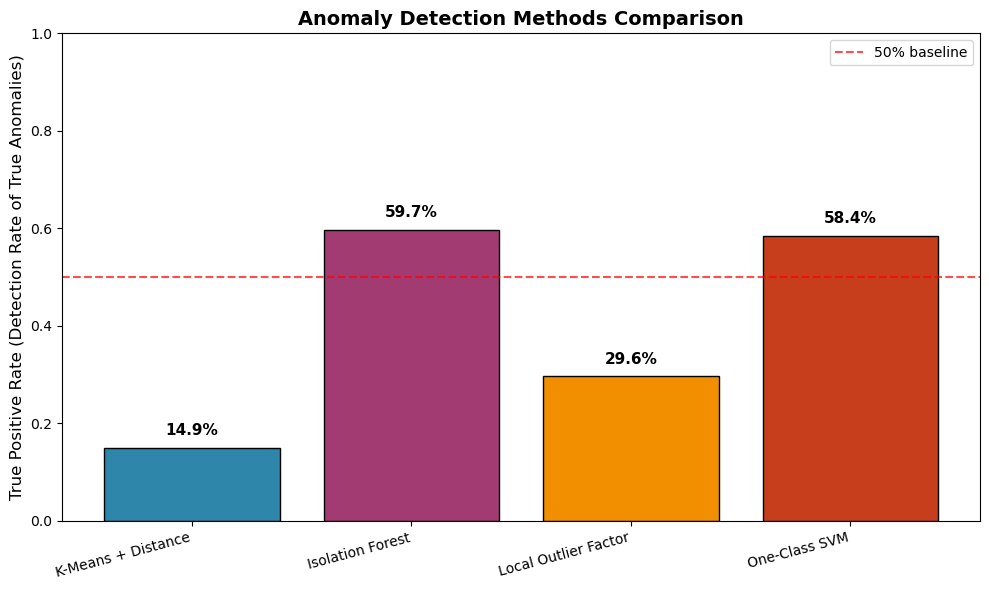

In [6]:
print("\n" + "="*60)
print("METHOD COMPARISON")
print("="*60)

# Get cluster-based anomaly detection (from previous notebook)
from scipy.spatial.distance import cdist
distances = np.min(cdist(X, kmeans.cluster_centers_), axis=1)
cluster_anomaly = (distances > anomaly_threshold).astype(int)
cluster_tpr = ((cluster_anomaly == 1) & (y == 1)).sum() / (y == 1).sum()

# Compile results
results_df = pd.DataFrame({
    'Method': ['K-Means + Distance', 'Isolation Forest', 'Local Outlier Factor', 'One-Class SVM'],
    'True Positive Rate (TPR)': [
        cluster_tpr,
        best_iso['true_positive_rate'],
        lof_tpr,
        best_svm['tpr']
    ],
    'Detection Rate': [
        (cluster_anomaly == 1).mean(),
        best_iso['detection_rate'],
        (lof_anomaly == 1).mean(),
        None  # Not calculated for SVM
    ]
})

print(results_df.to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = ax.bar(results_df['Method'], results_df['True Positive Rate (TPR)'], 
              color=colors, edgecolor='black')
ax.set_ylim(0, 1)
ax.set_ylabel('True Positive Rate (Detection Rate of True Anomalies)', fontsize=12)
ax.set_title('Anomaly Detection Methods Comparison', fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='50% baseline')
ax.legend()

# Add value labels
for bar, value in zip(bars, results_df['True Positive Rate (TPR)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{value:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/anomaly_methods_comparison.png', dpi=150)
plt.show()


In [7]:
print("\n" + "="*60)
print("ENSEMBLE METHOD (MAJORITY VOTING)")
print("="*60)

# Align predictions for overlapping samples
ensemble_anomalies = []

for idx in range(len(X)):
    votes = 0
    # K-Means vote
    if cluster_anomaly[idx] == 1:
        votes += 1
    # Isolation Forest vote
    if idx < len(iso_anomaly_final) and iso_anomaly_final[idx] == 1:
        votes += 1
    # Check if idx is in LOF sample
    if idx in sample_indices:
        lof_idx = np.where(sample_indices == idx)[0][0]
        if lof_anomaly[lof_idx] == 1:
            votes += 1
    
    # Majority voting (2 out of 3 vote)
    ensemble_anomalies.append(1 if votes >= 2 else 0)

ensemble_anomalies = np.array(ensemble_anomalies)
ensemble_tpr = ((ensemble_anomalies == 1) & (y == 1)).sum() / (y == 1).sum()
ensemble_fpr = ((ensemble_anomalies == 1) & (y == 0)).sum() / (y == 0).sum()

print(f"Ensemble Method (Majority Voting):")
print(f"  True Positive Rate: {ensemble_tpr:.2%}")
print(f"  False Positive Rate: {ensemble_fpr:.2%}")
print(f"  Precision: {((ensemble_anomalies == 1) & (y == 1)).sum() / (ensemble_anomalies == 1).sum():.2%}")



ENSEMBLE METHOD (MAJORITY VOTING)
Ensemble Method (Majority Voting):
  True Positive Rate: 23.76%
  False Positive Rate: 7.20%
  Precision: 76.74%


In [8]:
anomaly_scores = {
    'distance_score': distances / distances.max(),
    'isolation_score': iso_forest_final.score_samples(X),
    'ensemble_vote': ensemble_anomalies
}

# Normalize isolation scores (higher score = more normal)
iso_scores_normalized = (anomaly_scores['isolation_score'] - anomaly_scores['isolation_score'].min()) / \
                        (anomaly_scores['isolation_score'].max() - anomaly_scores['isolation_score'].min())
anomaly_scores['isolation_score_norm'] = 1 - iso_scores_normalized  # Invert: higher = more anomalous

# Combined anomaly score (weighted average)
combined_score = (anomaly_scores['distance_score'] * 0.4 + 
                  anomaly_scores['isolation_score_norm'] * 0.4 +
                  anomaly_scores['ensemble_vote'] * 0.2)

# Final anomaly decision (top 30% of combined score)
combined_threshold = np.percentile(combined_score, 70)
final_anomalies = (combined_score > combined_threshold).astype(int)

final_tpr = ((final_anomalies == 1) & (y == 1)).sum() / (y == 1).sum()
final_fpr = ((final_anomalies == 1) & (y == 0)).sum() / (y == 0).sum()
final_precision = ((final_anomalies == 1) & (y == 1)).sum() / (final_anomalies == 1).sum()

print(f"\nComprehensive Anomaly Scoring:")
print(f"  Combined Score Range: [{combined_score.min():.3f}, {combined_score.max():.3f}]")
print(f"  Threshold (70th percentile): {combined_threshold:.3f}")
print(f"  Final Anomalies Detected: {final_anomalies.sum():,} ({final_anomalies.mean():.2%})")
print(f"  True Positive Rate: {final_tpr:.2%}")
print(f"  False Positive Rate: {final_fpr:.2%}")
print(f"  Precision: {final_precision:.2%}")



Comprehensive Anomaly Scoring:
  Combined Score Range: [0.027, 0.937]
  Threshold (70th percentile): 0.202
  Final Anomalies Detected: 3,000 (30.00%)
  True Positive Rate: 38.66%
  False Positive Rate: 21.34%
  Precision: 64.43%


In [9]:
joblib.dump(iso_forest_final, '../data/models/isolation_forest.pkl')
joblib.dump(combined_threshold, '../data/models/combined_threshold.pkl')
joblib.dump(combined_score, '../data/processed/combined_scores.npy')
joblib.dump(final_anomalies, '../data/processed/final_anomalies.npy')

# Save anomaly types for detected anomalies
original_anomaly_types = pd.read_csv('../data/processed/anomaly_types.csv')
detected_anomaly_types = original_anomaly_types.iloc[final_anomalies == 1]

print("\n Anomaly detection complete!")
print("Models saved:")
print("  - isolation_forest.pkl")
print("  - combined_threshold.pkl")
print(f"  - Detected {(final_anomalies == 1).sum():,} anomalies")


 Anomaly detection complete!
Models saved:
  - isolation_forest.pkl
  - combined_threshold.pkl
  - Detected 3,000 anomalies
